In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/customer_churn_data.csv')
df.head()

,CustomerID,Gender,Age,Tenure,SubscriptionType,ContractType,MonthlyCharges,TotalCharges,PaymentMethod,LoginFrequency,SupportTickets,LastActiveDate,Churn
0,CUST101577,Female,64,55,Premium,Month-to-month,110.04,6067.58,E-check,15,1.0,2026-06-22,No
1,CUST100140,Female,74,19,Basic,Two year,20.50,376.18,E-check,17,1.0,2026-07-01,No
2,CUST100110,Female,61,60,Basic,Month-to-month,19.40,1168.89,E-check,9,1.0,2026-05-22,Yes
3,CUST100259,Male,33,62,Basic,Month-to-month,26.72,1671.46,Bank transfer,11,0.0,2026-07-31,No
4,CUST101391,Female,27,61,Basic,One year,34.24,2064.51,Credit card,10,0.0,2026-05-19,No


In [2]:
df.shape


(2015, 13)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        2015 non-null   str    
 1   Gender            2015 non-null   str    
 2   Age               2015 non-null   int64  
 3   Tenure            2015 non-null   int64  
 4   SubscriptionType  2015 non-null   str    
 5   ContractType      2015 non-null   str    
 6   MonthlyCharges    2015 non-null   float64
 7   TotalCharges      2001 non-null   float64
 8   PaymentMethod     1975 non-null   str    
 9   LoginFrequency    2015 non-null   int64  
 10  SupportTickets    1985 non-null   float64
 11  LastActiveDate    2015 non-null   str    
 12  Churn             2015 non-null   str    
dtypes: float64(3), int64(3), str(7)
memory usage: 204.8 KB


In [4]:
df.isnull().sum()

CustomerID           0
Gender               0
Age                  0
Tenure               0
SubscriptionType     0
ContractType         0
MonthlyCharges       0
TotalCharges        14
PaymentMethod       40
LoginFrequency       0
SupportTickets      30
LastActiveDate       0
Churn                0
dtype: int64

In [5]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [6]:
df['TotalCharges'].isnull().sum()


np.int64(0)

In [7]:
df['PaymentMethod'] = df['PaymentMethod'].fillna('Unknown')

In [8]:
df['PaymentMethod'].isnull().sum()

np.int64(0)

In [9]:
df['SupportTickets'] = df['SupportTickets'].fillna(0)

In [10]:
df['SupportTickets'].isnull().sum()

np.int64(0)

In [11]:
df.isnull().sum()

CustomerID          0
Gender              0
Age                 0
Tenure              0
SubscriptionType    0
ContractType        0
MonthlyCharges      0
TotalCharges        0
PaymentMethod       0
LoginFrequency      0
SupportTickets      0
LastActiveDate      0
Churn               0
dtype: int64

In [12]:
df['Gender'].unique()

<StringArray>
['Female', 'Male', 'FEMALE', 'MALE']
Length: 4, dtype: str

In [13]:
df['Gender'] = df['Gender'].str.strip().str.capitalize()

In [14]:
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [15]:
df.duplicated().sum()

np.int64(15)

In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(2000, 13)

In [19]:
df['Age'].describe()

count    2000.000000
mean       45.673000
std        16.631367
min        -5.000000
25%        32.000000
50%        45.000000
75%        60.000000
max       150.000000
Name: Age, dtype: float64

In [20]:
df[(df['Age'] < 18) | (df['Age'] > 100)]

,CustomerID,Gender,Age,Tenure,SubscriptionType,ContractType,MonthlyCharges,TotalCharges,PaymentMethod,LoginFrequency,SupportTickets,LastActiveDate,Churn
948,CUST101238,Male,130,4,Basic,One year,16.23,105.95,Mailed check,15,2.0,2026-07-09,No
1312,CUST101160,Female,0,58,Standard,Month-to-month,65.11,3798.23,E-check,12,2.0,2026-07-31,No
1354,CUST101326,Male,-5,44,Standard,Month-to-month,52.29,2275.89,E-check,12,3.0,2026-06-12,No
1474,CUST101264,Female,1,38,Premium,One year,76.80,2935.03,Bank transfer,9,2.0,2026-07-16,No
1720,CUST100846,Female,150,68,Premium,Month-to-month,100.19,6834.86,Mailed check,11,1.0,2026-07-07,No


In [21]:
median_age = df['Age'].median()
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = median_age

In [22]:
df['Age'].describe()

count    2000.000000
mean       45.647500
std        16.256518
min        18.000000
25%        32.000000
50%        45.000000
75%        60.000000
max        74.000000
Name: Age, dtype: float64

In [23]:
df.to_csv('../data/cleaned/customer_churn_cleaned.csv', index=False)

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [25]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print(churn_rate)

Churn
No     1505
Yes     495
Name: count, dtype: int64
Churn
No     75.25
Yes    24.75
Name: proportion, dtype: float64


C:\Users\panda\AppData\Local\Temp\ipykernel_19072\2545456281.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


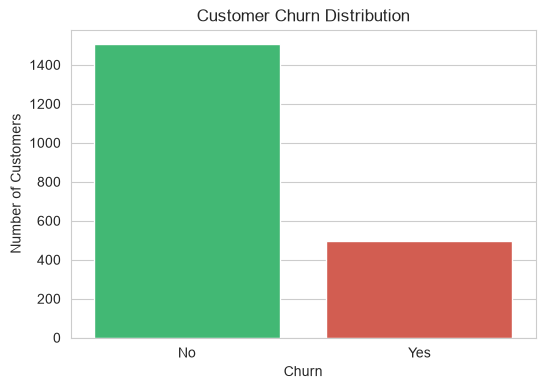

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [27]:
contract_churn = df.groupby('ContractType')['Churn'].value_counts(normalize=True).unstack() * 100
print(contract_churn)

Churn                  No        Yes
ContractType                        
Month-to-month  66.580087  33.419913
One year        88.105727  11.894273
Two year        85.933504  14.066496


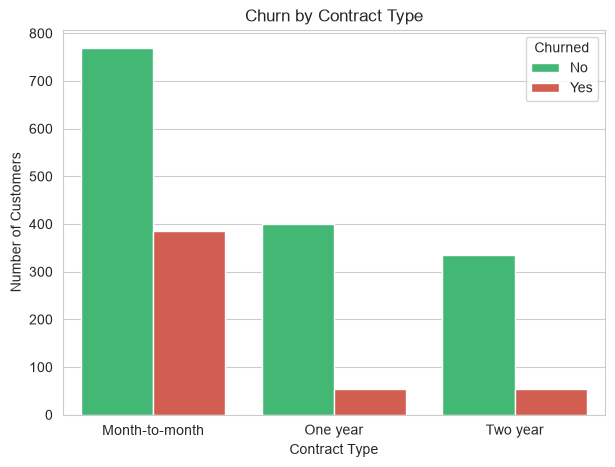

In [28]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='ContractType', hue='Churn', 
              order=['Month-to-month', 'One year', 'Two year'],
              palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churned')
plt.show()

## Finding: Churn by Contract Type

Customers on month-to-month contracts show a substantially higher churn rate 
than those on one-year or two-year contracts. This suggests contract length 
may be an important factor in retention, though this is a correlation 
observed in the data — not proof that contract type directly causes churn.

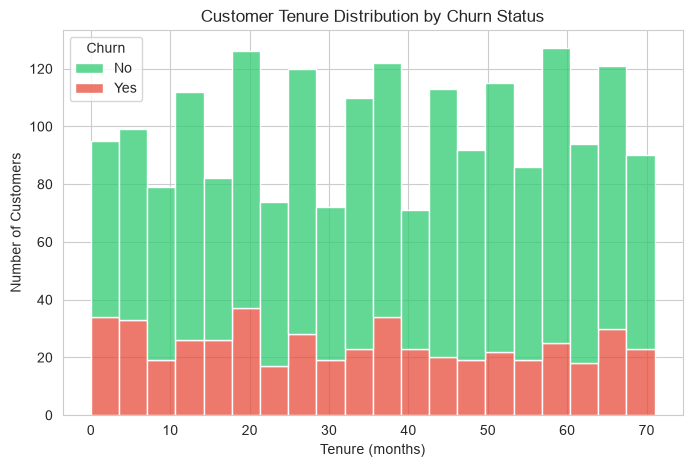

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack', 
             palette=['#2ecc71', '#e74c3c'], bins=20)
plt.title('Customer Tenure Distribution by Churn Status')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

In [31]:
avg_tenure_churn = df.groupby('Churn')['Tenure'].mean()
print(avg_tenure_churn)

Churn
No     37.004651
Yes    33.759596
Name: Tenure, dtype: float64


## Finding: Tenure vs Churn

Churned customers have a slightly lower average tenure (~34 months) compared 
to retained customers (~37 months), but the difference is modest. Unlike 
contract type, tenure alone does not appear to be a strong predictor of 
churn in this dataset.

In [32]:
avg_login_churn = df.groupby('Churn')['LoginFrequency'].mean()
print(avg_login_churn)

Churn
No     12.196013
Yes    11.713131
Name: LoginFrequency, dtype: float64


C:\Users\panda\AppData\Local\Temp\ipykernel_19072\1544500069.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='LoginFrequency', palette=['#2ecc71', '#e74c3c'])


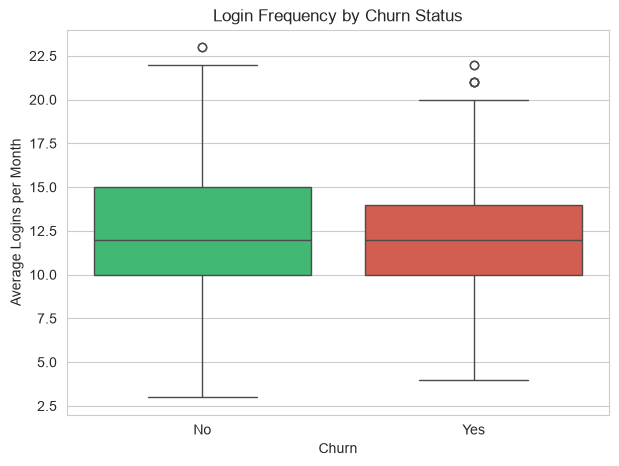

In [33]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='LoginFrequency', palette=['#2ecc71', '#e74c3c'])
plt.title('Login Frequency by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Average Logins per Month')
plt.show()

## Finding: Login Frequency vs Churn

Login frequency shows almost no difference between churned and retained 
customers (similar medians and spread in both groups). This suggests 
usage frequency alone is not a meaningful churn indicator in this dataset.

In [34]:
avg_tickets_churn = df.groupby('Churn')['SupportTickets'].mean()
print(avg_tickets_churn)

Churn
No     1.209302
Yes    1.341414
Name: SupportTickets, dtype: float64


C:\Users\panda\AppData\Local\Temp\ipykernel_19072\3475126316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='SupportTickets', palette=['#2ecc71', '#e74c3c'])


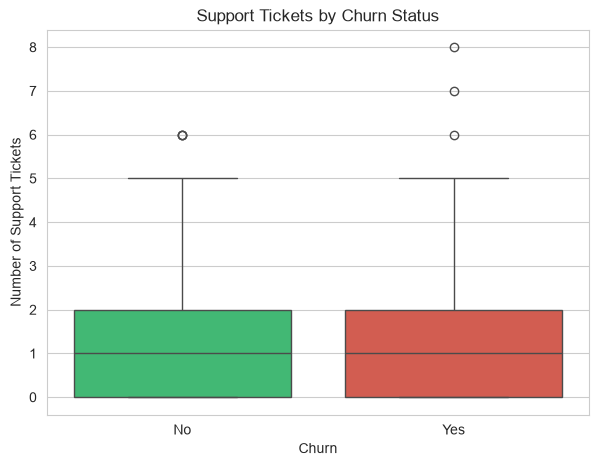

In [35]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='SupportTickets', palette=['#2ecc71', '#e74c3c'])
plt.title('Support Tickets by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Number of Support Tickets')
plt.show()

In [36]:
high_tickets = df[df['SupportTickets'] >= 3]
churn_rate_high_tickets = high_tickets['Churn'].value_counts(normalize=True) * 100
print(churn_rate_high_tickets)

Churn
No     70.0
Yes    30.0
Name: proportion, dtype: float64


## Finding: Support Tickets vs Churn

Customers with 3 or more support tickets churn at 30%, compared to the 
overall baseline of ~25%. Churned customers also show higher support 
ticket counts on average. This suggests support friction is a moderate 
but real churn risk factor.

In [37]:
subscription_churn = df.groupby('SubscriptionType')['Churn'].value_counts(normalize=True).unstack() * 100
print(subscription_churn)

Churn                    No        Yes
SubscriptionType                      
Basic             76.376989  23.623011
Premium           73.299748  26.700252
Standard          75.063613  24.936387


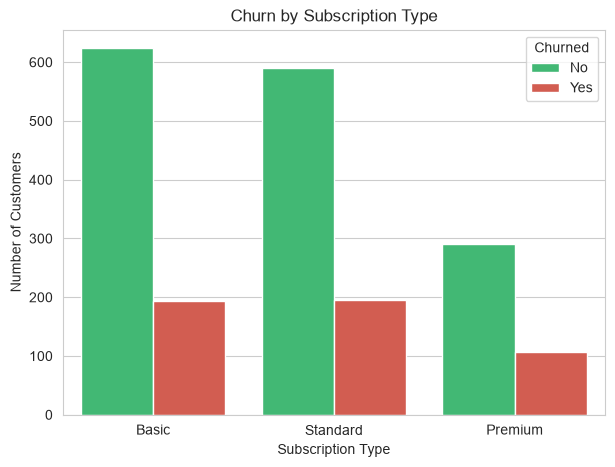

In [38]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='SubscriptionType', hue='Churn',
              order=['Basic', 'Standard', 'Premium'],
              palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churned')
plt.show()

## Finding: Subscription Type vs Churn

Churn rates are similar across Basic, Standard, and Premium subscription 
tiers, all close to the overall ~25% baseline. Subscription type does not 
appear to be a meaningful churn driver on its own.

In [39]:
total_monthly_revenue = df['MonthlyCharges'].sum()
churned_monthly_revenue = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
revenue_at_risk_pct = (churned_monthly_revenue / total_monthly_revenue) * 100

print(f"Total Monthly Revenue: ${total_monthly_revenue:,.2f}")
print(f"Monthly Revenue Lost to Churn: ${churned_monthly_revenue:,.2f}")
print(f"Percentage of Revenue at Risk: {revenue_at_risk_pct:.1f}%")

Total Monthly Revenue: $100,015.82
Monthly Revenue Lost to Churn: $25,176.55
Percentage of Revenue at Risk: 25.2%


In [40]:
annual_revenue_lost = churned_monthly_revenue * 12
print(f"Estimated Annual Revenue Lost to Churn: ${annual_revenue_lost:,.2f}")

Estimated Annual Revenue Lost to Churn: $302,118.60


## Finding: Revenue at Risk

Churned customers represent 25.2% of total monthly recurring revenue 
(~$25,177/month), which projects to roughly $300K in lost revenue annually 
if this churn pattern continues. This reframes churn from a customer-count 
problem into a direct revenue problem.